# DATA WRALING


## 1.Mengumpulkan data

In [20]:
import os

if 'google.colab' in str(get_ipython()) and not os.path.exists('data'):
    !git clone https://github.com/YudhaAlfarizi/jakarta-pm25-svr-forecasting.git
    %cd jakarta-pm25-svr-forecasting

print("Direktori kerja saat ini:", os.getcwd())
print("Isi folder data/:", os.listdir('data') if os.path.exists('data') else 'folder data/ belum ada')

Direktori kerja saat ini: /content/jakarta-pm25-svr-forecasting
Isi folder data/: ['pm25_daily.csv', 'ispu_dki_all.csv']


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 150)

RAW_PATH = 'data/ispu_dki_all.csv'
OUT_PATH = 'data/pm25_daily.csv'

INTERPOLATION_LIMIT = 3

## 2. Memuat Data Mentah
File ini berisi data gabungan dari 5 stasiun pemantau kualitas udara (SPKU) DKI Jakarta. Setiap baris merepresentasikan satu tanggal, dengan kolom `stasiun` menunjukkan stasiun yang nilai ISPU-nya tertinggi pada hari itu.

In [22]:
df_raw = pd.read_csv(RAW_PATH, parse_dates=['tanggal'])
df_raw = df_raw.sort_values('tanggal').reset_index(drop=True)

print(f"Jumlah baris   : {len(df_raw):,}")
print(f"Rentang tanggal: {df_raw['tanggal'].min().date()} s.d. {df_raw['tanggal'].max().date()}")
print(f"Kolom          : {list(df_raw.columns)}")
df_raw.head()

Jumlah baris   : 5,538
Rentang tanggal: 2010-01-01 s.d. 2025-02-28
Kolom          : ['tanggal', 'stasiun', 'pm25', 'pm10', 'so2', 'co', 'o3', 'no2', 'max', 'critical', 'categori']


,tanggal,stasiun,pm25,pm10,so2,co,o3,no2,max,critical,categori
0,2010-01-01,DKI1 (Bunderan HI),NaN,60.0,4.0,73.0,27.0,14.0,73.0,CO,SEDANG
1,2010-01-02,DKI1 (Bunderan HI),NaN,32.0,2.0,16.0,33.0,9.0,33.0,O3,BAIK
2,2010-01-03,DKI1 (Bunderan HI),NaN,27.0,2.0,19.0,20.0,9.0,27.0,PM10,BAIK
3,2010-01-04,DKI1 (Bunderan HI),NaN,22.0,2.0,16.0,15.0,6.0,22.0,PM10,BAIK
4,2010-01-05,DKI1 (Bunderan HI),NaN,25.0,2.0,17.0,15.0,8.0,25.0,PM10,BAIK


In [23]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5538 entries, 0 to 5537
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   tanggal   5538 non-null   datetime64[ns]
 1   stasiun   5537 non-null   object        
 2   pm25      1516 non-null   float64       
 3   pm10      5223 non-null   float64       
 4   so2       5408 non-null   float64       
 5   co        5450 non-null   float64       
 6   o3        5434 non-null   float64       
 7   no2       5432 non-null   float64       
 8   max       5537 non-null   float64       
 9   critical  5534 non-null   object        
 10  categori  5538 non-null   object        
dtypes: datetime64[ns](1), float64(7), object(3)
memory usage: 476.1+ KB


## 3. Memeriksa Ketersediaan PM2.5

`pm25` tidak tersedia sepanjang rentang file. Sel di bawah mencari tanggal pertama dan terakhir yang datanya valid (bukan NaN).

In [24]:
pm25_valid = df_raw.dropna(subset=['pm25'])

tgl_awal = pm25_valid['tanggal'].min()
tgl_akhir = pm25_valid['tanggal'].max()

print(f"Tanggal PM2.5 pertama tersedia : {tgl_awal.date()}")
print(f"Tanggal PM2.5 terakhir tersedia: {tgl_akhir.date()}")
print(f"Jumlah baris dengan pm25 terisi: {len(pm25_valid):,} dari {len(df_raw):,} baris total")

# Persentase pm25 kosong per tahun, untuk melihat sejak kapan datanya konsisten ada
persen_kosong_per_tahun = (
    df_raw.assign(tahun=df_raw['tanggal'].dt.year)
    .groupby('tahun')['pm25']
    .apply(lambda s: s.isna().mean() * 100)
    .round(1)
)
print("\nPersentase pm25 KOSONG per tahun:")
print(persen_kosong_per_tahun)

Tanggal PM2.5 pertama tersedia : 2021-01-01
Tanggal PM2.5 terakhir tersedia: 2025-02-28
Jumlah baris dengan pm25 terisi: 1,516 dari 5,538 baris total

Persentase pm25 KOSONG per tahun:
tahun
2010    100.0
2011    100.0
2012    100.0
2013    100.0
2014    100.0
2015    100.0
2016    100.0
2017    100.0
2018    100.0
2019    100.0
2020    100.0
2021      0.5
2022      0.0
2023      0.3
2024      0.3
2025      0.0
Name: pm25, dtype: float64


## 4. Menentukan Periode Analisis

Berdasarkan pemeriksaan di atas, periode analisis dipilih mulai dari tanggal pertama PM2.5 tersedia secara konsisten (yaitu awal tahun 2021 setelah data tahun sebelumnya 100% kosong) sampai tanggal terakhir pada file.

In [25]:
tahun_mulai = persen_kosong_per_tahun[persen_kosong_per_tahun < 100].index.min()
TANGGAL_MULAI = pd.Timestamp(year=int(tahun_mulai), month=1, day=1)
TANGGAL_AKHIR = df_raw['tanggal'].max()

print(f"Periode analisis dipakai: {TANGGAL_MULAI.date()} s.d. {TANGGAL_AKHIR.date()}")

df = df_raw[(df_raw['tanggal'] >= TANGGAL_MULAI) & (df_raw['tanggal'] <= TANGGAL_AKHIR)].copy()
df = df.set_index('tanggal')

# Kolom yang dipakai untuk pemodelan; kolom turunan (max, critical, categori)
# dan stasiun tidak disertakan karena bocor informasi atau tidak bisa diprediksi
KOLOM_DIPAKAI = ['pm25', 'pm10', 'so2', 'co', 'o3', 'no2']
df = df[KOLOM_DIPAKAI]

print(f"Jumlah baris pada periode ini: {len(df):,}")
df.head()

Periode analisis dipakai: 2021-01-01 s.d. 2025-02-28
Jumlah baris pada periode ini: 1,520


,pm25,pm10,so2,co,o3,no2
tanggal,,,,,,
2021-01-01,58.0,38.0,2.0,11.0,65.0,6.0
2021-01-02,86.0,58.0,15.0,22.0,38.0,5.0
2021-01-03,93.0,64.0,14.0,20.0,35.0,5.0
2021-01-04,49.0,30.0,NaN,9.0,77.0,7.0
2021-01-05,89.0,59.0,15.0,19.0,42.0,7.0


## 5. Memeriksa Tanggal yang Hilang dari Deret Harian

Jumlah baris pada file belum tentu sama dengan jumlah hari kalender pada periode tersebut. Sel berikut menyusun ulang data ke frekuensi harian penuh (`asfreq('D')`) agar tanggal yang hilang terlihat sebagai baris kosong (NaN).

In [26]:
jumlah_hari_seharusnya = (TANGGAL_AKHIR - TANGGAL_MULAI).days + 1
jumlah_tanggal_ada = df.index.nunique()

print(f"Jumlah hari seharusnya (kalender): {jumlah_hari_seharusnya:,}")
print(f"Jumlah tanggal yang ada di file  : {jumlah_tanggal_ada:,}")
print(f"Jumlah tanggal HILANG            : {jumlah_hari_seharusnya - jumlah_tanggal_ada:,}")
print(f"Jumlah baris duplikat (tanggal sama muncul >1x): {df.index.duplicated().sum()}")

# Susun ulang ke frekuensi harian penuh
df = df[~df.index.duplicated(keep='first')]
df = df.asfreq('D')

print(f"\nSetelah asfreq('D'), jumlah baris: {len(df):,}")

Jumlah hari seharusnya (kalender): 1,520
Jumlah tanggal yang ada di file  : 1,520
Jumlah tanggal HILANG            : 0
Jumlah baris duplikat (tanggal sama muncul >1x): 0

Setelah asfreq('D'), jumlah baris: 1,520


## 6. Memeriksa Missing Value per Kolom

In [27]:
missing_report = pd.DataFrame({
    'jumlah_NaN': df.isna().sum(),
    'persen_NaN': (df.isna().mean() * 100).round(2)
})
print(missing_report)

tanggal_pm25_kosong = df[df['pm25'].isna()].index
print(f"\nTanggal dengan pm25 kosong ({len(tanggal_pm25_kosong)} hari):")
for t in tanggal_pm25_kosong:
    print(" -", t.date())

      jumlah_NaN  persen_NaN
pm25           4        0.26
pm10         200       13.16
so2           22        1.45
co            22        1.45
o3            23        1.51
no2           14        0.92

Tanggal dengan pm25 kosong (4 hari):
 - 2021-07-12
 - 2021-11-28
 - 2023-09-30
 - 2024-01-04


## 7. Menganalisis Panjang Celah (Gap) per Kolom

Sebuah kolom bisa punya banyak NaN yang tersebar sebagai celah pendek (1-3 hari), atau terkonsentrasi sebagai celah panjang (berminggu-minggu). Keduanya butuh perlakuan berbeda: celah pendek aman diinterpolasi, celah panjang tidak.

In [28]:
def analisis_gap(series, nama_kolom):
    """Mengembalikan daftar panjang celah NaN berturut-turut pada sebuah series."""
    is_na = series.isna()
    if not is_na.any():
        print(f"{nama_kolom}: tidak ada missing value")
        return []
    grup = (is_na != is_na.shift()).cumsum()
    panjang_gap = is_na.groupby(grup).agg(['first', 'size'])
    panjang_gap = panjang_gap[panjang_gap['first']]['size'].tolist()
    panjang_gap.sort(reverse=True)
    terpanjang = panjang_gap[:5]
    print(f"{nama_kolom}: {len(panjang_gap)} celah, total {is_na.sum()} hari NaN, "
          f"5 celah terpanjang: {terpanjang}")
    return panjang_gap

print("Ringkasan panjang celah tiap kolom:\n")
gap_info = {}
for kolom in KOLOM_DIPAKAI:
    gap_info[kolom] = analisis_gap(df[kolom], kolom)

Ringkasan panjang celah tiap kolom:

pm25: 4 celah, total 4 hari NaN, 5 celah terpanjang: [1, 1, 1, 1]
pm10: 30 celah, total 200 hari NaN, 5 celah terpanjang: [66, 46, 14, 12, 8]
so2: 16 celah, total 22 hari NaN, 5 celah terpanjang: [3, 3, 3, 1, 1]
co: 14 celah, total 22 hari NaN, 5 celah terpanjang: [3, 2, 2, 2, 2]
o3: 15 celah, total 23 hari NaN, 5 celah terpanjang: [8, 2, 1, 1, 1]
no2: 11 celah, total 14 hari NaN, 5 celah terpanjang: [2, 2, 2, 1, 1]


In [29]:
# Detail celah PANJANG (>= 7 hari) untuk setiap kolom — ini yang TIDAK akan diinterpolasi
print(f"Celah dengan panjang >= 7 hari (di atas ambang INTERPOLATION_LIMIT={INTERPOLATION_LIMIT}):\n")
for kolom in KOLOM_DIPAKAI:
    is_na = df[kolom].isna()
    if not is_na.any():
        continue
    grup = (is_na != is_na.shift()).cumsum()
    for g, sub in df[kolom].groupby(grup):
        if is_na[sub.index].all() and len(sub) >= 7:
            print(f"  {kolom}: {sub.index[0].date()} s.d. {sub.index[-1].date()} "
                  f"({len(sub)} hari)")

Celah dengan panjang >= 7 hari (di atas ambang INTERPOLATION_LIMIT=3):

  pm10: 2021-09-21 s.d. 2021-09-27 (7 hari)
  pm10: 2023-04-19 s.d. 2023-04-30 (12 hari)
  pm10: 2023-05-02 s.d. 2023-06-16 (46 hari)
  pm10: 2023-06-18 s.d. 2023-07-01 (14 hari)
  pm10: 2023-07-03 s.d. 2023-09-06 (66 hari)
  pm10: 2024-11-13 s.d. 2024-11-20 (8 hari)
  o3: 2021-12-24 s.d. 2021-12-31 (8 hari)


## 8. Visualisasi Awal Sebelum Penanganan Missing Value

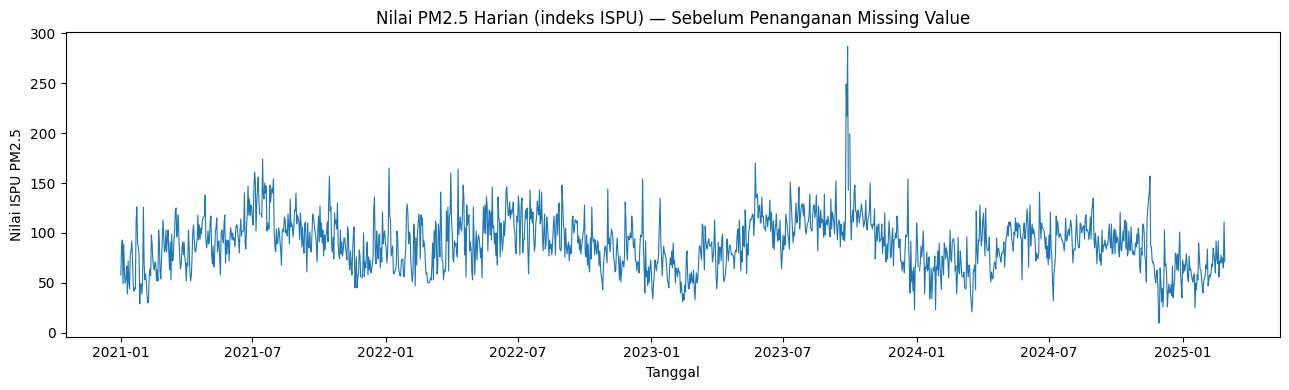

In [30]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df.index, df['pm25'], linewidth=0.8)
ax.set_title('Nilai PM2.5 Harian (indeks ISPU) — Sebelum Penanganan Missing Value')
ax.set_ylabel('Nilai ISPU PM2.5')
ax.set_xlabel('Tanggal')
plt.tight_layout()
plt.savefig('docs/pm25_sebelum_cleaning.png', dpi=120)
plt.show()

## 9. Menangani Missing Value
Aturan:
- Celah **≤ `INTERPOLATION_LIMIT` hari** diisi dengan interpolasi berbasis waktu.
- Celah **lebih panjang dibiarkan kosong** (tidak diisi), supaya tidak menciptakan data buatan yang tidak realistis.

In [31]:
df_bersih = df.copy()

for kolom in KOLOM_DIPAKAI:
    df_bersih[kolom] = df_bersih[kolom].interpolate(
        method='time',
        limit=INTERPOLATION_LIMIT,
        limit_area='inside'
    )

print("Missing value SEBELUM interpolasi:")
print(df.isna().sum())
print("\nMissing value SESUDAH interpolasi (celah > "
      f"{INTERPOLATION_LIMIT} hari tetap kosong):")
print(df_bersih.isna().sum())

Missing value SEBELUM interpolasi:
pm25      4
pm10    200
so2      22
co       22
o3       23
no2      14
dtype: int64

Missing value SESUDAH interpolasi (celah > 3 hari tetap kosong):
pm25      0
pm10    144
so2       0
co        0
o3        5
no2       0
dtype: int64


## 10. Verifikasi Hasil dan Statistik Deskriptif

In [32]:
print("Statistik deskriptif nilai PM2.5 (indeks ISPU) setelah pembersihan:\n")
print(df_bersih['pm25'].describe().round(2))

print("\nKorelasi pm25 dengan polutan lain (data yang tidak kosong):")
print(df_bersih[KOLOM_DIPAKAI].corr()['pm25'].round(2).sort_values(ascending=False))

Statistik deskriptif nilai PM2.5 (indeks ISPU) setelah pembersihan:

count    1520.00
mean       89.78
std        26.70
min        10.00
25%        71.00
50%        90.00
75%       107.00
max       287.00
Name: pm25, dtype: float64

Korelasi pm25 dengan polutan lain (data yang tidak kosong):
pm25    1.00
pm10    0.79
co      0.43
o3      0.24
no2     0.07
so2    -0.07
Name: pm25, dtype: float64


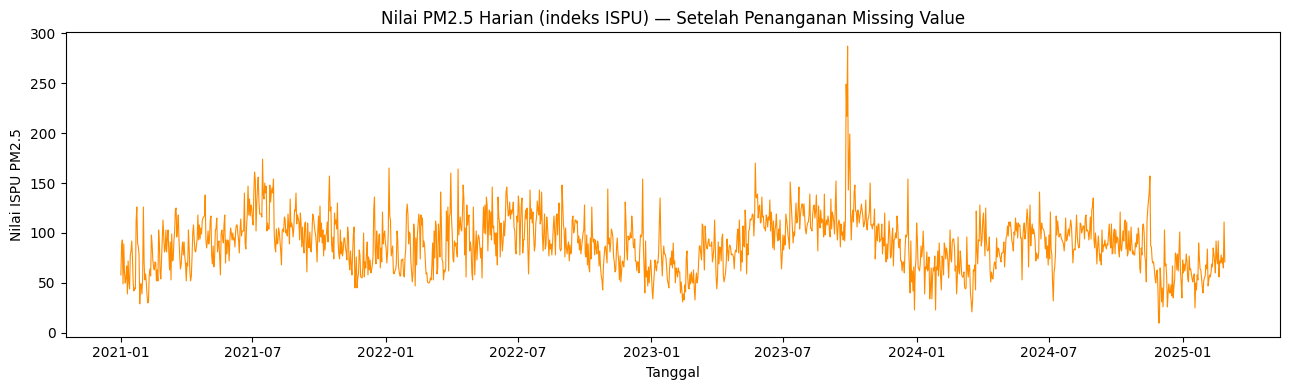

In [33]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df_bersih.index, df_bersih['pm25'], linewidth=0.8, color='darkorange')
ax.set_title('Nilai PM2.5 Harian (indeks ISPU) — Setelah Penanganan Missing Value')
ax.set_ylabel('Nilai ISPU PM2.5')
ax.set_xlabel('Tanggal')
plt.tight_layout()
plt.savefig('docs/pm25_sesudah_cleaning.png', dpi=120)
plt.show()

## 11. Ringkasan Kualitas Data


In [34]:
print("=" * 60)
print("RINGKASAN")
print("=" * 60)
print(f"Periode dipakai       : {TANGGAL_MULAI.date()} s.d. {TANGGAL_AKHIR.date()}")
print(f"Jumlah hari (kalender): {jumlah_hari_seharusnya:,}")
print(f"Tanggal hilang        : {jumlah_hari_seharusnya - jumlah_tanggal_ada:,}")
print(f"pm25 NaN sebelum      : {df['pm25'].isna().sum()}")
print(f"pm25 NaN sesudah      : {df_bersih['pm25'].isna().sum()}")
print(f"Batas interpolasi     : {INTERPOLATION_LIMIT} hari")
print()
for kolom in KOLOM_DIPAKAI:
    n_gap = len(gap_info[kolom])
    total_nan = df[kolom].isna().sum()
    gap_panjang = [g for g in gap_info[kolom] if g > INTERPOLATION_LIMIT]
    print(f"{kolom:6s}: {total_nan:4d} hari NaN dalam {n_gap:3d} celah "
          f"({len(gap_panjang)} celah > {INTERPOLATION_LIMIT} hari)")
print("=" * 60)

RINGKASAN UNTUK docs/dataset.md
Periode dipakai       : 2021-01-01 s.d. 2025-02-28
Jumlah hari (kalender): 1,520
Tanggal hilang        : 0
pm25 NaN sebelum      : 4
pm25 NaN sesudah      : 0
Batas interpolasi     : 3 hari

pm25  :    4 hari NaN dalam   4 celah (0 celah > 3 hari)
pm10  :  200 hari NaN dalam  30 celah (10 celah > 3 hari)
so2   :   22 hari NaN dalam  16 celah (0 celah > 3 hari)
co    :   22 hari NaN dalam  14 celah (0 celah > 3 hari)
o3    :   23 hari NaN dalam  15 celah (1 celah > 3 hari)
no2   :   14 hari NaN dalam  11 celah (0 celah > 3 hari)


## 12. Menyimpan Hasil


In [35]:
os.makedirs('data', exist_ok=True)
df_bersih.to_csv(OUT_PATH, index=True, index_label='tanggal')
print(f"Tersimpan: {OUT_PATH}  ({len(df_bersih)} baris)")

df_bersih.head()

Tersimpan: data/pm25_daily.csv  (1520 baris)


,pm25,pm10,so2,co,o3,no2
tanggal,,,,,,
2021-01-01,58.0,38.0,2.0,11.0,65.0,6.0
2021-01-02,86.0,58.0,15.0,22.0,38.0,5.0
2021-01-03,93.0,64.0,14.0,20.0,35.0,5.0
2021-01-04,49.0,30.0,14.5,9.0,77.0,7.0
2021-01-05,89.0,59.0,15.0,19.0,42.0,7.0
